In [6]:
! pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [9]:
df = pd.read_csv("laptopPrice.csv")

df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [10]:
print("Shape of dataset:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape of dataset: (823, 19)
<class 'pandas.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   brand              823 non-null    str  
 1   processor_brand    823 non-null    str  
 2   processor_name     823 non-null    str  
 3   processor_gnrtn    823 non-null    str  
 4   ram_gb             823 non-null    str  
 5   ram_type           823 non-null    str  
 6   ssd                823 non-null    str  
 7   hdd                823 non-null    str  
 8   os                 823 non-null    str  
 9   os_bit             823 non-null    str  
 10  graphic_card_gb    823 non-null    str  
 11  weight             823 non-null    str  
 12  warranty           823 non-null    str  
 13  Touchscreen        823 non-null    str  
 14  msoffice           823 non-null    str  
 15  Price              823 non-null    int64
 16  rating             823 non-null    str  
 17 

brand                0
processor_brand      0
processor_name       0
processor_gnrtn      0
ram_gb               0
ram_type             0
ssd                  0
hdd                  0
os                   0
os_bit               0
graphic_card_gb      0
weight               0
warranty             0
Touchscreen          0
msoffice             0
Price                0
rating               0
Number of Ratings    0
Number of Reviews    0
dtype: int64

In [ ]:
df.dropna(inplace=True) 

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [19]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 576410115.1504695


In [20]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.7042241051300422


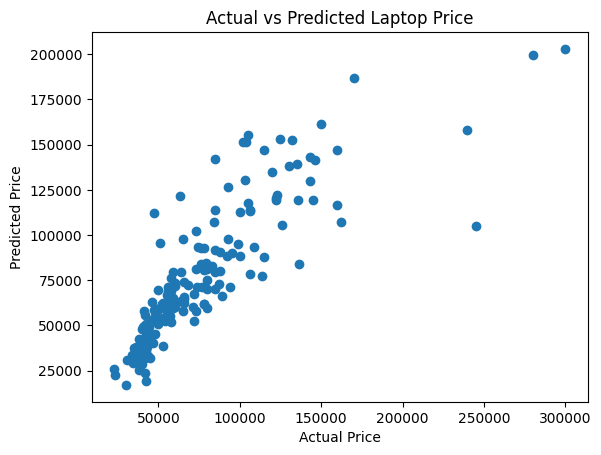

In [21]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Laptop Price")

plt.show()

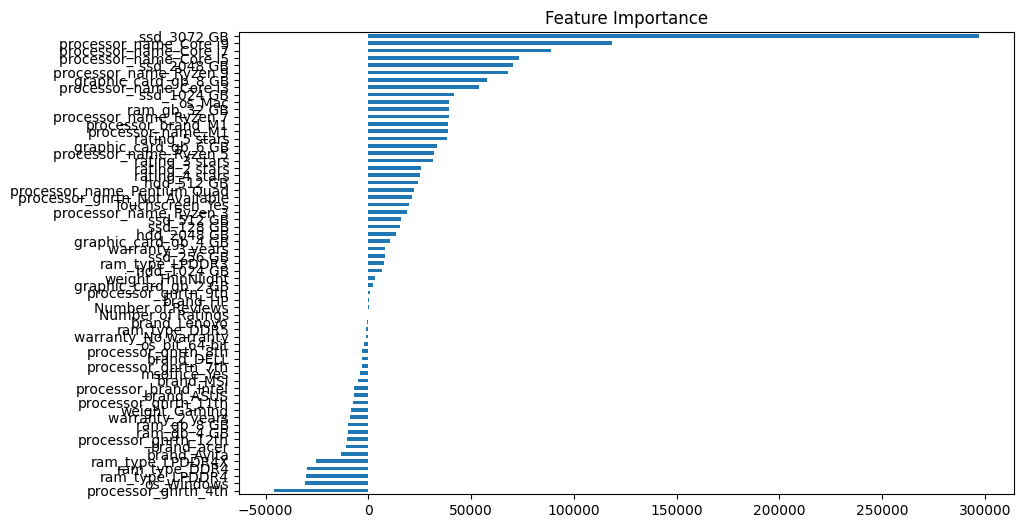

In [22]:
importance = pd.Series(model.coef_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Feature Importance")

plt.show()

In [23]:
joblib.dump(model, "laptop_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
model = joblib.load("laptop_price_model.pkl")

In [25]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Laptop Price:", prediction[0])

Predicted Laptop Price: 35108.577716102445


In [26]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred[:10])

Predicted Prices:
[117594.53590074  31921.87808502  35171.43542156  49256.13471488
  76295.4472068   66151.70512044 143219.57956918  42235.83082446
  58598.06947098  51057.88431053]


In [27]:
sample = X.iloc[[0]]

print("Input Data:")
print(sample)

prediction = model.predict(sample)

print("Predicted Laptop Price:", prediction[0])

Input Data:
   Number of Ratings  Number of Reviews  brand_ASUS  brand_Avita  brand_DELL  \
0                  3                  0        True        False       False   

   brand_HP  brand_Lenovo  brand_MSI  brand_acer  processor_brand_Intel  ...  \
0     False         False      False       False                   True  ...   

   weight_ThinNlight  warranty_2 years  warranty_3 years  \
0              False             False             False   

   warranty_No warranty  Touchscreen_Yes  msoffice_Yes  rating_2 stars  \
0                  True            False         False            True   

   rating_3 stars  rating_4 stars  rating_5 stars  
0           False           False           False  

[1 rows x 63 columns]
Predicted Laptop Price: 35108.577716102445


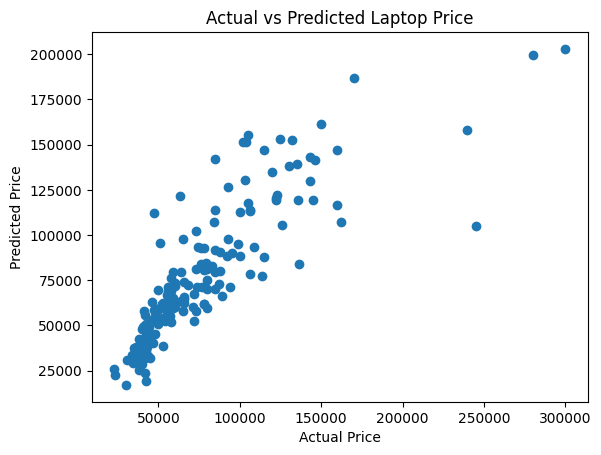

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Laptop Price")

plt.show()

In [30]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("Model Accuracy (R2 Score):", r2)

Model Accuracy (R2 Score): 0.7042241051300422
